# ***Unsupervised Models: K-Means & Hierarchical Clustering***

In [1]:
# Library
import os
import kagglehub
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder , LabelEncoder , StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV , GridSearchCV
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score ,confusion_matrix, roc_curve, auc , silhouette_score
from sklearn.inspection import DecisionBoundaryDisplay
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage , fcluster
from sklearn.metrics.cluster import adjusted_rand_score
from sklearn.impute import SimpleImputer
from sklearn.datasets import make_blobs

# ***Data Preprocessing***

In [2]:
# Download the Breast cancer dataset from Kaggle
dataset_path = kagglehub.dataset_download('uciml/breast-cancer-wisconsin-data')

# construct the full path to the adult11.csv file.
file_path = os.path.join(dataset_path, 'data.csv')

# Load the dataset
bcwd = pd.read_csv(file_path)
bcwd

Using Colab cache for faster access to the 'breast-cancer-wisconsin-data' dataset.


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


In [3]:
# null values
bcwd.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [4]:
# dropp unnecessary column Unnamed: 32 & id
bcwd.drop('id', axis=1, inplace=True)
bcwd.drop('Unnamed: 32', axis=1, inplace=True)
bcwd

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [5]:
bcwd['diagnosis'].value_counts() # print diagnosis values

,count
diagnosis,
B,357
M,212


In [6]:
# Encode diagnosis (label encoding)
bcwd['diagnosis'] = bcwd['diagnosis'].map({'M': 1, 'B': 0})
x_bcwd = bcwd.drop('diagnosis', axis=1) #Separate features (X) and target (y)
y_bcwd = bcwd['diagnosis']
bcwd

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,1,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,1,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,1,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,1,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [7]:
# Standardize numerical features
scaler = StandardScaler()
X_bcwd_train_scaled = scaler.fit_transform(x_bcwd)
X_bcwd_test_scaled = scaler.transform(x_bcwd)

# ***Models Building & Evaluation then Visualization***

```
# K-means
```

In [8]:
# K-means
kmeans_bcwd = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_bcwd.fit(X_bcwd_train_scaled)

KMeans(n_clusters=2, n_init=10, random_state=42)

In [9]:
# Compute a Silhouette Score
clusters_kmeans_pred_bcwd = kmeans_bcwd.predict(X_bcwd_train_scaled)
kmeans_silhouette_bcwd = silhouette_score(X_bcwd_train_scaled, clusters_kmeans_pred_bcwd)
print(f"K-Means Silhouette Score (BC): {kmeans_silhouette_bcwd:.4f}")

K-Means Silhouette Score (BC): 0.3434


In [10]:
# Compare clusters to true labels with a simple table
table_bcwd = pd.crosstab(y_bcwd, clusters_kmeans_pred_bcwd, rownames=['True Labels'], colnames=['K-Means Clusters'])
print("\nK-Means Cluster vs. True Labels (BC):")
print(table_bcwd)


K-Means Cluster vs. True Labels (BC):
K-Means Clusters    0    1
True Labels               
0                 339   18
1                  36  176


```
# Hierarchical Clustering
```

In [11]:
# Sampling the data for Hierarchical Clustering
sample_size = 1000
np.random.seed(42)
sample_indices = np.random.choice(X_bcwd_train_scaled.shape[0], size=sample_size)
X_sample_bcwd = X_bcwd_train_scaled[sample_indices]
y_sample_bcwd = y_bcwd.iloc[sample_indices]

In [12]:
# Define linkage methods to test
linkage_methods = ['ward', 'complete', 'average', 'single']
hierarchical_results_bcwd = {}

for method in linkage_methods:
    # Apply AgglomerativeClustering on full data
    hierarchical_bcwd = AgglomerativeClustering(n_clusters=2, linkage=method)
    clusters_hierarchical_pred_bcwd = hierarchical_bcwd.fit_predict(X_bcwd_train_scaled)

    # Evaluate on full data
    silhouette_avg = silhouette_score(X_bcwd_train_scaled, clusters_hierarchical_pred_bcwd)
    hierarchical_results_bcwd[method] = silhouette_avg

    # Store the best result for later visualization
    if method == 'complete': # Use complete linkage for the main visualization
        best_agg_labels_bcwd = clusters_hierarchical_pred_bcwd
        best_hierarchical_method_bcwd = method

print("\nAll Hierarchical Clustering Silhouette Scores:")
for method, score in hierarchical_results_bcwd.items():
    print(f"  {method}: {score:.4f}")


All Hierarchical Clustering Silhouette Scores:
  ward: 0.3394
  complete: 0.6607
  average: 0.6340
  single: 0.6607


In [13]:
# Compare clusters to true labels (Best Method)
agg_crosstab_bcwd = pd.crosstab(y_bcwd, best_agg_labels_bcwd, rownames=['True Labels'], colnames=['Hierarchical Clusters'])
print("\nHierarchical Cluster vs. True Labels:")
print(agg_crosstab_bcwd)


Hierarchical Cluster vs. True Labels:
Hierarchical Clusters    0  1
True Labels                  
0                      357  0
1                      210  2



PCA to 2D


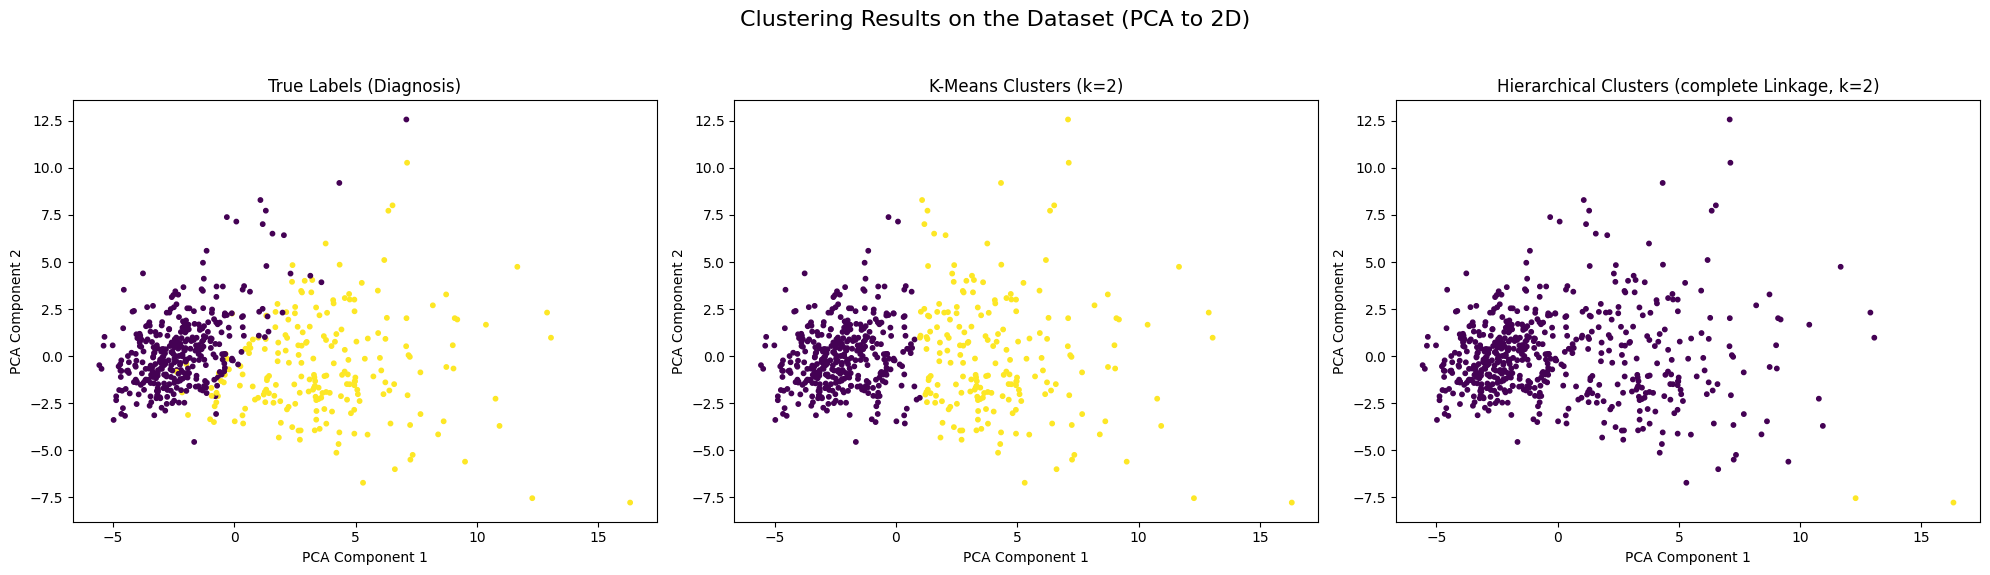

In [14]:
# PCA to 2D
print("\nPCA to 2D")

# Reduce dimensionality to 2D using PCA
pca_bcwd = PCA(n_components=2)
X_pca_bcwd = pca_bcwd.fit_transform(X_bcwd_train_scaled)

# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Clustering Results on the Dataset (PCA to 2D)', fontsize=16)

# Plot 1: True Labels
scatter1 = axes[0].scatter(X_pca_bcwd[:, 0], X_pca_bcwd[:, 1], c=y_bcwd, cmap='viridis', s=10)
axes[0].set_title('True Labels (Diagnosis)')
axes[0].set_xlabel('PCA Component 1')
axes[0].set_ylabel('PCA Component 2')

# Plot 2: K-Means
scatter2 = axes[1].scatter(X_pca_bcwd[:, 0], X_pca_bcwd[:, 1], c=clusters_kmeans_pred_bcwd, cmap='viridis', s=10)
axes[1].set_title('K-Means Clusters (k=2)')
axes[1].set_xlabel('PCA Component 1')
axes[1].set_ylabel('PCA Component 2')

# Plot 3: Hierarchical (Best Method)
scatter3 = axes[2].scatter(X_pca_bcwd[:, 0], X_pca_bcwd[:, 1], c=best_agg_labels_bcwd, cmap='viridis', s=10)
axes[2].set_title(f'Hierarchical Clusters ({best_hierarchical_method_bcwd} Linkage, k=2)')
axes[2].set_xlabel('PCA Component 1')
axes[2].set_ylabel('PCA Component 2')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])


Dendrogram for Hierarchical Clustering


Text(0, 0.5, 'Distance')

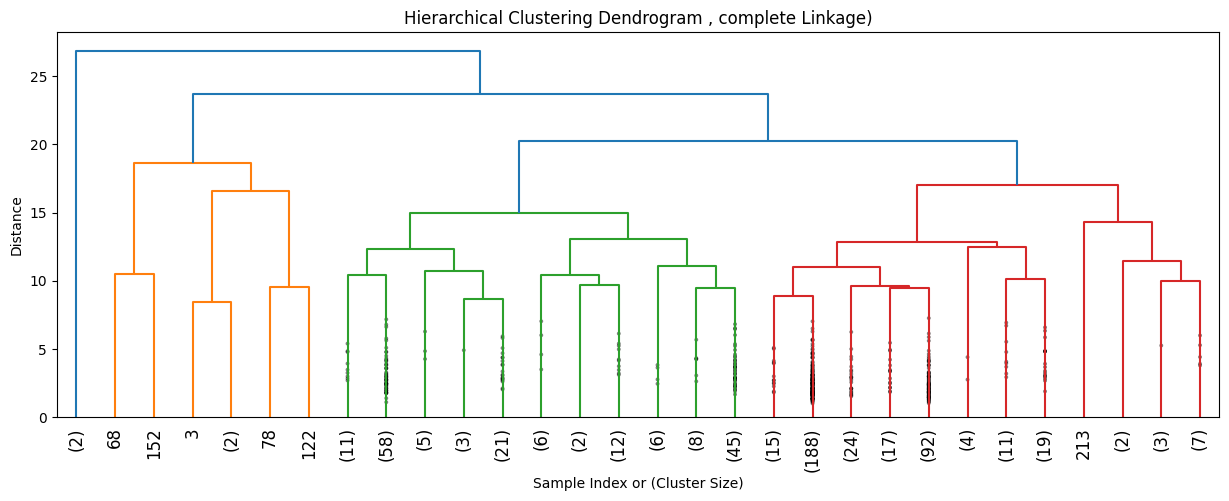

In [15]:
# --- Dendrogram for Hierarchical Clustering ---
print("\nDendrogram for Hierarchical Clustering")

# Perform linkage on the full data
linked_bcwd = linkage(X_bcwd_train_scaled, method=best_hierarchical_method_bcwd)

# Plot the dendrogram
plt.figure(figsize=(15,5))
dendrogram(
    linked_bcwd,
    orientation='top',
    truncate_mode='lastp',
    p=30,
    show_leaf_counts=True,
    leaf_rotation=90.,
    leaf_font_size=12.,
    show_contracted=True,
)
plt.title(f'Hierarchical Clustering Dendrogram , {best_hierarchical_method_bcwd} Linkage)')
plt.xlabel('Sample Index or (Cluster Size)')
plt.ylabel('Distance')

# **Model Performance Comparison**

In [16]:
print("\n--- Model Performance Comparison ---")
print(f"K-Means Silhouette Score: {kmeans_silhouette_bcwd:.4f}")
print(f"Hierarchical Clustering ({best_hierarchical_method_bcwd} linkage) Silhouette Score: {hierarchical_results_bcwd[best_hierarchical_method_bcwd]:.4f}")

print("\nK-Means Cluster vs. True Labels:\n")
print(table_bcwd)

print("\nHierarchical Cluster vs. True Labels:\n")
print(agg_crosstab_bcwd)


--- Model Performance Comparison ---
K-Means Silhouette Score: 0.3434
Hierarchical Clustering (complete linkage) Silhouette Score: 0.6607

K-Means Cluster vs. True Labels:

K-Means Clusters    0    1
True Labels               
0                 339   18
1                  36  176

Hierarchical Cluster vs. True Labels:

Hierarchical Clusters    0  1
True Labels                  
0                      357  0
1                      210  2


/tmp/ipykernel_4531/2099674047.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=silhouette_scores, palette='viridis')


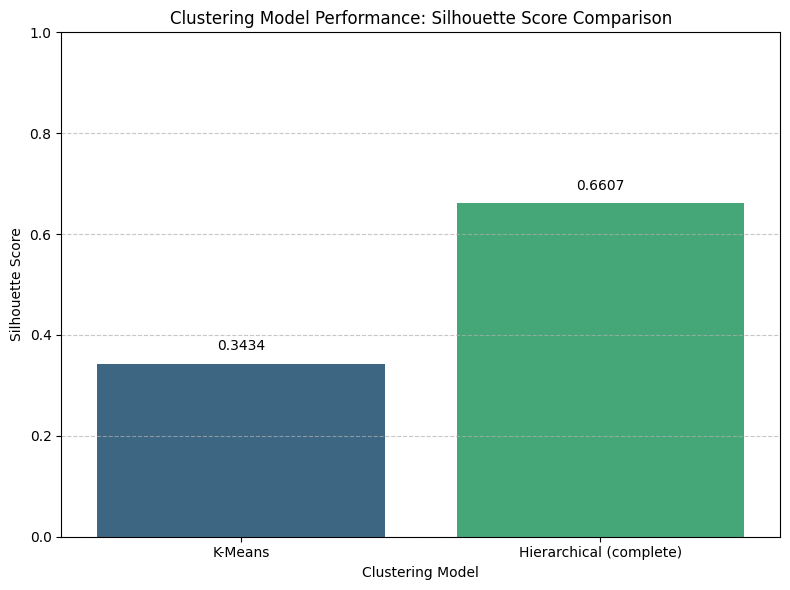

In [17]:
models = ['K-Means', f'Hierarchical ({best_hierarchical_method_bcwd})']
silhouette_scores = [kmeans_silhouette_bcwd, hierarchical_results_bcwd[best_hierarchical_method_bcwd]]

plt.figure(figsize=(8, 6))
sns.barplot(x=models, y=silhouette_scores, palette='viridis')
plt.title('Clustering Model Performance: Silhouette Score Comparison')
plt.xlabel('Clustering Model')
plt.ylabel('Silhouette Score')
plt.ylim(0, 1) # Silhouette scores are between -1 and 1
plt.grid(axis='y', linestyle='--', alpha=0.7)

for index, score in enumerate(silhouette_scores):
    plt.text(index, score + 0.02, f'{score:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()